TASK 1 - Data Loading and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Dataset Load

In [4]:
df = pd.read_csv("Housing.csv")


In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
#dataset shape
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 545
Columns: 13


In [7]:
df.info() #dataset info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
target='price'
print("Target:",target)

Target: price


In [9]:
features=df.drop('price',axis=1)
print(features.columns)

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [10]:
#missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

TASK 2 - Data Cleaning

In [11]:
#remove missing value 
df = df.dropna()

In [12]:
#remove duplicate row
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [13]:
#converting categorical columns
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [14]:
#one hot encoding

df = pd.get_dummies(df, drop_first=True)

In [15]:
#checking
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Task 3 — Model Building

In [16]:
#splitting the dataset in train and test (80/20)

x = df.drop('price',axis=1)
y = df['price']

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [18]:
#train the linear regression model

lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [19]:
#prediction
y_pred = lr.predict(x_test)

In [20]:
#Evaluation

#MAE 
mae = mean_absolute_error(y_test,y_pred)
print(mae)

970043.403920164


In [21]:
#RMSE
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

1324506.9600914388


In [22]:
#R2
r2 = r2_score(y_test,y_pred)
print(r2)

0.6529242642153184


In [23]:
# now Random Forest 
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [24]:
rf.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [25]:
#prediction
pred_rf = rf.predict(x_test)

In [26]:
#MAE
mae_rf=mean_absolute_error(y_test,pred_rf)
print("MAE :",mae_rf)

MAE : 1021546.0353211008


In [27]:
#RMSE
rmse_rf=np.sqrt(mean_squared_error(y_test,pred_rf))
print("RMSE :",rmse_rf)

RMSE : 1400565.9728553821


In [28]:
#R2
r2_rf = r2_score(y_test,pred_rf)
print("R2 :",r2_rf)

R2 : 0.611918531405699


In [29]:
# COMPARE THE MODELS 

comparison=pd.DataFrame({

'Model':['Linear Regression',
         'Random Forest'],

'MAE':[mae,
       mae_rf],

'RMSE':[rmse,
        rmse_rf],

'R2':[r2,
      r2_rf]

})



In [30]:
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


TASK 4 - Visualizaion

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


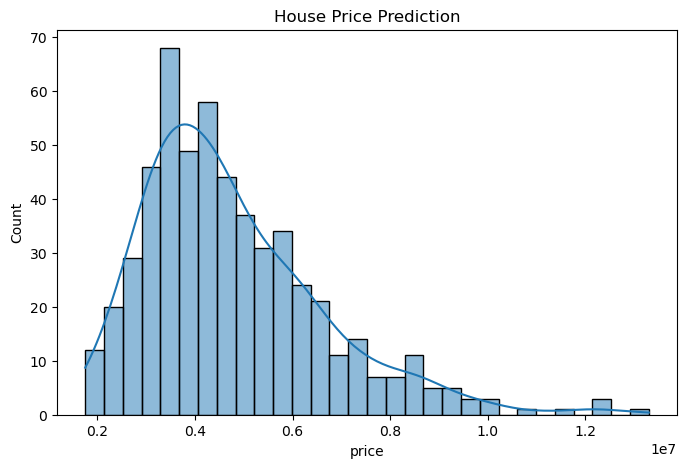

In [37]:
#Chart 1
# HISTOGRAM

plt.figure(figsize = (8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("House Price Prediction")
plt.savefig("chart1.png")
plt.show()

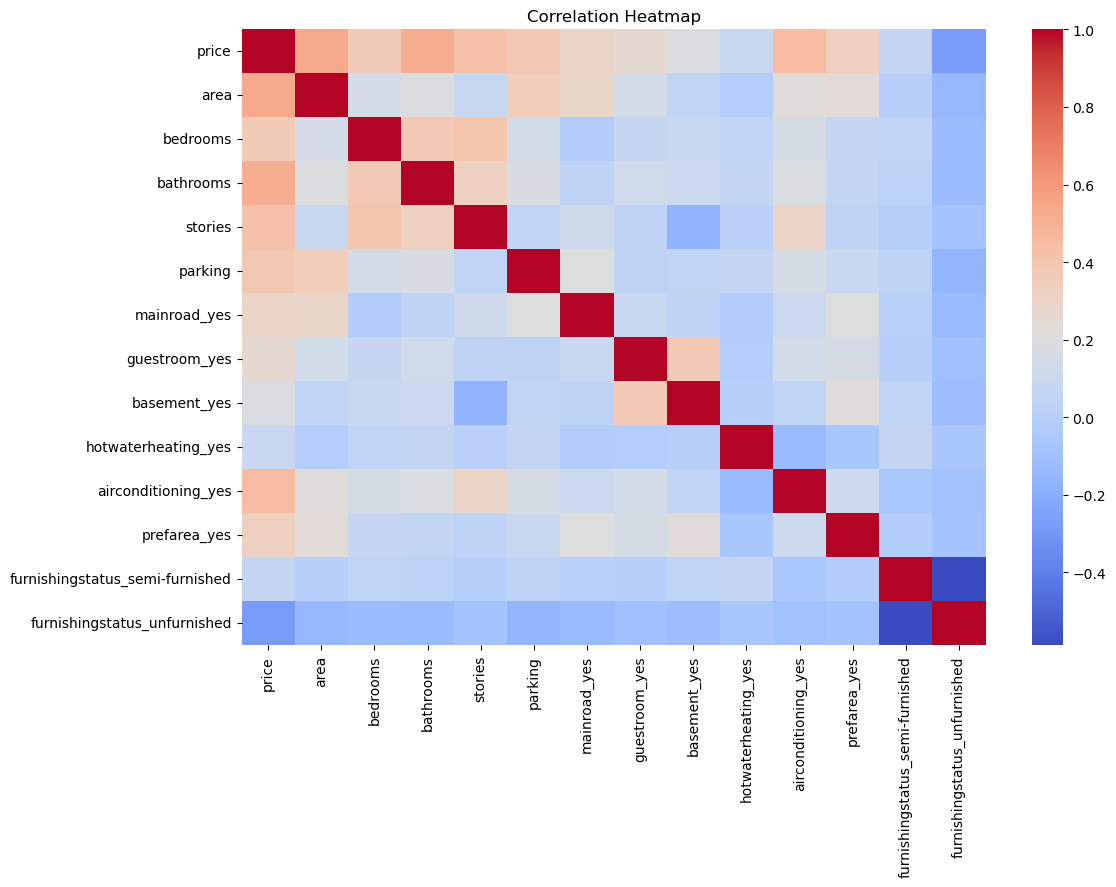

In [38]:
#Chart 2
# CORRELATION HEATMAP

plt.figure(figsize=(12,8))
corr=df.corr()
sns.heatmap(corr,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("chart2.png")
plt.show()


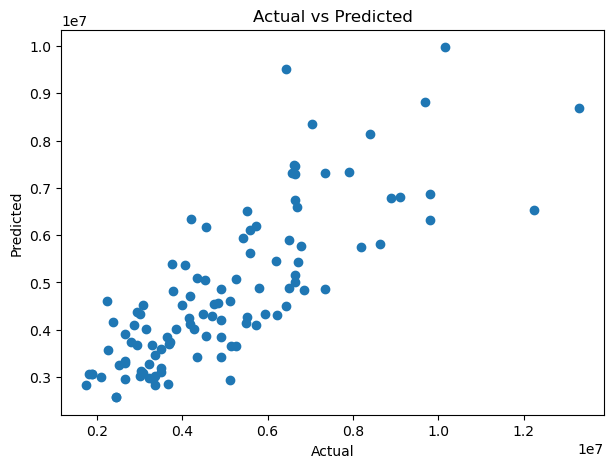

In [39]:
#Chart 3
# ACTUAL VS PREDICTED

plt.figure(figsize=(7,5))
plt.scatter(y_test,pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.savefig("chart3.png")
plt.show()

Task 5 - Insights & Summary

From above we can say that, the features that influences the house price the most are area of the house, number of bathrooms, air conditioning and location in preferred area.  In accuracy among the models tested, the Linear Regression provided better performance, achieving a higher R2 Score of 0.653 which means it was able to explain about 65% of the variation in house prices. It also produced lower prediction errors (MAE ≈ 970,000 and RMSE ≈ 1,324,000) compared to the Random Forest model. The surprising observation in data was that amenities like furnishing and air conditioning had a noticeable impact on prices (significantly higher prices), even for houses with similar sizes. Based on the findings, real state business should focus on promoting premium features and houses located in preferred areas and Real Estate companies should use data-driven models to estimate property prices more accurately instead of relying only on market intuition.